In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_curve
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb

# Load ML-ready dataset
CSV_PATH = os.path.expanduser("~/sentinelmesh/data/processed/phase1_ml_ready.csv")
df = pd.read_csv(CSV_PATH)

feature_cols = [c for c in df.columns if c not in ['unified_label', 'is_attack']]
X = df[feature_cols]
y_binary = df['is_attack'].astype(int)
y_multi  = df['unified_label']

print(f"✅ Loaded: {df.shape}")
print(f"Features : {len(feature_cols)}")
print(f"\nClass distribution BEFORE SMOTE:\n{y_binary.value_counts()}")

✅ Loaded: (241527, 41)
Features : 39

Class distribution BEFORE SMOTE:
is_attack
1    221527
0     20000
Name: count, dtype: int64


In [2]:
# === Train/Test Split FIRST (before SMOTE) ===

# IMPORTANT: split BEFORE SMOTE — never apply SMOTE to test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")
print(f"\nTrain attack ratio : {y_train.mean():.2%}")
print(f"Test attack ratio  : {y_test.mean():.2%}")

Train set : (193221, 39)
Test set  : (48306, 39)

Train attack ratio : 91.72%
Test attack ratio  : 91.72%


In [3]:
# === Apply SMOTE to training set only ===

print("Applying SMOTE to training set...")
print(f"Before → Attack: {y_train.sum():,} | Benign: {(y_train==0).sum():,}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After  → Attack: {y_train_sm.sum():,} | Benign: {(y_train_sm==0).sum():,}")
print(f"\nNew training shape: {X_train_sm.shape}")
print(f"Class balance     : {pd.Series(y_train_sm).value_counts(normalize=True).round(3).to_dict()}")

# Convert SMOTEd data back to DataFrame/Series for CV and reporting
X_train_sm_df = pd.DataFrame(X_train_sm, columns=feature_cols)
y_train_sm_ser = pd.Series(y_train_sm, name='is_attack')

print(f"& SMOTEd training DataFrame shape: {X_train_sm_df.shape}")

Applying SMOTE to training set...
Before → Attack: 177,221 | Benign: 16,000
After  → Attack: 177,221 | Benign: 177,221

New training shape: (354442, 39)
Class balance     : {1: 0.5, 0: 0.5}
& SMOTEd training DataFrame shape: (354442, 39)


In [4]:
# === Model factories + Stratified 5-Fold CV with benign-F1 threshold tuning ===

from typing import Callable, Tuple

def make_rf() -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

def make_xgb() -> xgb.XGBClassifier:
    return xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,   # already balanced via SMOTE
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

def make_lgb() -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

def tune_threshold_cv(
    model_factory: Callable,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5
) -> Tuple[float, pd.DataFrame]:
    """
    Stratified 5-fold CV on SMOTEd training data.
    For each fold:
      - fit model
      - compute P(attack) on validation fold
      - choose threshold that maximises benign-class F1 (label 0)
    Returns:
      - final threshold (mean across folds)
      - per-fold metrics DataFrame
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    thresholds = []
    rows = []

    candidate_ts = np.linspace(0.05, 0.95, 19)  # 0.05, 0.10, ..., 0.95

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = model_factory()
        model.fit(X_tr, y_tr)

        probas_val = model.predict_proba(X_val)[:, 1]  # P(attack)

        # Default threshold (0.5) metrics
        preds_default = (probas_val >= 0.5).astype(int)
        f1_weighted_default = f1_score(y_val, preds_default, average='weighted')
        f1_benign_default   = f1_score(y_val, preds_default, pos_label=0)

        # Search threshold that maximises benign F1
        best_t = 0.5
        best_f1_benign = -1.0
        best_f1_weighted = f1_weighted_default

        for t in candidate_ts:
            preds_t = (probas_val >= t).astype(int)
            f1_benign_t   = f1_score(y_val, preds_t, pos_label=0)
            f1_weighted_t = f1_score(y_val, preds_t, average='weighted')
            if f1_benign_t > best_f1_benign:
                best_f1_benign   = f1_benign_t
                best_f1_weighted = f1_weighted_t
                best_t           = float(t)

        thresholds.append(best_t)
        rows.append({
            'fold': fold,
            't_default': 0.5,
            't_best': best_t,
            'f1_weighted_default': f1_weighted_default,
            'f1_benign_default':   f1_benign_default,
            'f1_weighted_best':    best_f1_weighted,
            'f1_benign_best':      best_f1_benign,
        })

        print(
            f"Fold {fold}: default t=0.50 → benign F1={f1_benign_default:.3f}, "
            f"best t={best_t:.2f} → benign F1={best_f1_benign:.3f}, "
            f"weighted F1={best_f1_weighted:.3f}"
        )

    df_cv = pd.DataFrame(rows)
    t_final = float(np.mean(thresholds))

    print("\n=== CV Summary ===")
    print(df_cv.to_string(index=False))
    print(f"\nRecommended threshold (mean over folds): {t_final:.3f}")

    return t_final, df_cv

In [5]:
# === Train Random Forest with SMOTEd training set + CV threshold tuning ===

print("Training Random Forest (final model)...")
rf = make_rf()
rf.fit(X_train_sm_df, y_train_sm_ser)

print("\nRunning 5-fold CV for threshold tuning (benign-class F1)...")
rf_tuned_thresh, rf_cv = tune_threshold_cv(make_rf, X_train_sm_df, y_train_sm_ser)

# Evaluate on untouched test set using tuned threshold
rf_probas_test = rf.predict_proba(X_test)[:, 1]
rf_preds_tuned = (rf_probas_test >= rf_tuned_thresh).astype(int)

rf_f1_weighted = f1_score(y_test, rf_preds_tuned, average='weighted')
rf_f1_benign   = f1_score(y_test, rf_preds_tuned, pos_label=0)

print(f"\n& Random Forest — Weighted F1 (tuned t={rf_tuned_thresh:.3f}): {rf_f1_weighted:.4f}")
print(f"& Random Forest — Benign-class F1 (label 0): {rf_f1_benign:.4f}")

print("\nClassification Report (tuned threshold):")
print(classification_report(y_test, rf_preds_tuned, target_names=['Benign', 'Attack']))

Training Random Forest (final model)...

Running 5-fold CV for threshold tuning (benign-class F1)...
Fold 1: default t=0.50 → benign F1=0.963, best t=0.40 → benign F1=0.965, weighted F1=0.965
Fold 2: default t=0.50 → benign F1=0.964, best t=0.40 → benign F1=0.965, weighted F1=0.965
Fold 3: default t=0.50 → benign F1=0.963, best t=0.40 → benign F1=0.965, weighted F1=0.965
Fold 4: default t=0.50 → benign F1=0.963, best t=0.40 → benign F1=0.965, weighted F1=0.965
Fold 5: default t=0.50 → benign F1=0.964, best t=0.40 → benign F1=0.966, weighted F1=0.967

=== CV Summary ===
 fold  t_default  t_best  f1_weighted_default  f1_benign_default  f1_weighted_best  f1_benign_best
    1        0.5     0.4             0.962694           0.963236          0.964621        0.964617
    2        0.5     0.4             0.963443           0.963948          0.965312        0.965288
    3        0.5     0.4             0.962639           0.963126          0.964860        0.964838
    4        0.5     0.4    

In [6]:
# === Train XGBoost with SMOTEd training set + CV threshold tuning ===

print("Training XGBoost (final model)...")
xgb_model = make_xgb()
xgb_model.fit(X_train_sm_df, y_train_sm_ser)

print("\nRunning 5-fold CV for threshold tuning (benign-class F1)...")
xgb_tuned_thresh, xgb_cv = tune_threshold_cv(make_xgb, X_train_sm_df, y_train_sm_ser)

# Evaluate on untouched test set using tuned threshold
xgb_probas_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds_tuned = (xgb_probas_test >= xgb_tuned_thresh).astype(int)

xgb_f1_weighted = f1_score(y_test, xgb_preds_tuned, average='weighted')
xgb_f1_benign   = f1_score(y_test, xgb_preds_tuned, pos_label=0)

print(f"\n& XGBoost — Weighted F1 (tuned t={xgb_tuned_thresh:.3f}): {xgb_f1_weighted:.4f}")
print(f"& XGBoost — Benign-class F1 (label 0): {xgb_f1_benign:.4f}")

print("\nClassification Report (tuned threshold):")
print(classification_report(y_test, xgb_preds_tuned, target_names=['Benign', 'Attack']))

Training XGBoost (final model)...

Running 5-fold CV for threshold tuning (benign-class F1)...
Fold 1: default t=0.50 → benign F1=0.967, best t=0.50 → benign F1=0.967, weighted F1=0.968
Fold 2: default t=0.50 → benign F1=0.969, best t=0.50 → benign F1=0.969, weighted F1=0.969
Fold 3: default t=0.50 → benign F1=0.968, best t=0.55 → benign F1=0.968, weighted F1=0.968
Fold 4: default t=0.50 → benign F1=0.969, best t=0.50 → benign F1=0.969, weighted F1=0.969
Fold 5: default t=0.50 → benign F1=0.968, best t=0.50 → benign F1=0.968, weighted F1=0.969

=== CV Summary ===
 fold  t_default  t_best  f1_weighted_default  f1_benign_default  f1_weighted_best  f1_benign_best
    1        0.5    0.50             0.967526           0.967370          0.967526        0.967370
    2        0.5    0.50             0.969472           0.969307          0.969472        0.969307
    3        0.5    0.55             0.967920           0.967744          0.967822        0.967861
    4        0.5    0.50          

In [7]:
# === Train LightGBM with SMOTEd training set + CV threshold tuning ===

print("Training LightGBM (final model)...")
lgb_model = make_lgb()
lgb_model.fit(X_train_sm_df, y_train_sm_ser)

print("\nRunning 5-fold CV for threshold tuning (benign-class F1)...")
lgb_tuned_thresh, lgb_cv = tune_threshold_cv(make_lgb, X_train_sm_df, y_train_sm_ser)

# Evaluate on untouched test set using tuned threshold
lgb_probas_test = lgb_model.predict_proba(X_test)[:, 1]
lgb_preds_tuned = (lgb_probas_test >= lgb_tuned_thresh).astype(int)

lgb_f1_weighted = f1_score(y_test, lgb_preds_tuned, average='weighted')
lgb_f1_benign   = f1_score(y_test, lgb_preds_tuned, pos_label=0)

print(f"\n& LightGBM — Weighted F1 (tuned t={lgb_tuned_thresh:.3f}): {lgb_f1_weighted:.4f}")
print(f"& LightGBM — Benign-class F1 (label 0): {lgb_f1_benign:.4f}")

print("\nClassification Report (tuned threshold):")
print(classification_report(y_test, lgb_preds_tuned, target_names=['Benign', 'Attack']))

Training LightGBM (final model)...

Running 5-fold CV for threshold tuning (benign-class F1)...
Fold 1: default t=0.50 → benign F1=0.966, best t=0.50 → benign F1=0.966, weighted F1=0.966
Fold 2: default t=0.50 → benign F1=0.968, best t=0.50 → benign F1=0.968, weighted F1=0.968
Fold 3: default t=0.50 → benign F1=0.966, best t=0.50 → benign F1=0.966, weighted F1=0.967
Fold 4: default t=0.50 → benign F1=0.967, best t=0.45 → benign F1=0.967, weighted F1=0.968
Fold 5: default t=0.50 → benign F1=0.967, best t=0.50 → benign F1=0.967, weighted F1=0.967

=== CV Summary ===
 fold  t_default  t_best  f1_weighted_default  f1_benign_default  f1_weighted_best  f1_benign_best
    1        0.5    0.50             0.966157           0.965961          0.966157        0.965961
    2        0.5    0.50             0.967779           0.967577          0.967779        0.967577
    3        0.5    0.50             0.966650           0.966443          0.966650        0.966443
    4        0.5    0.45         

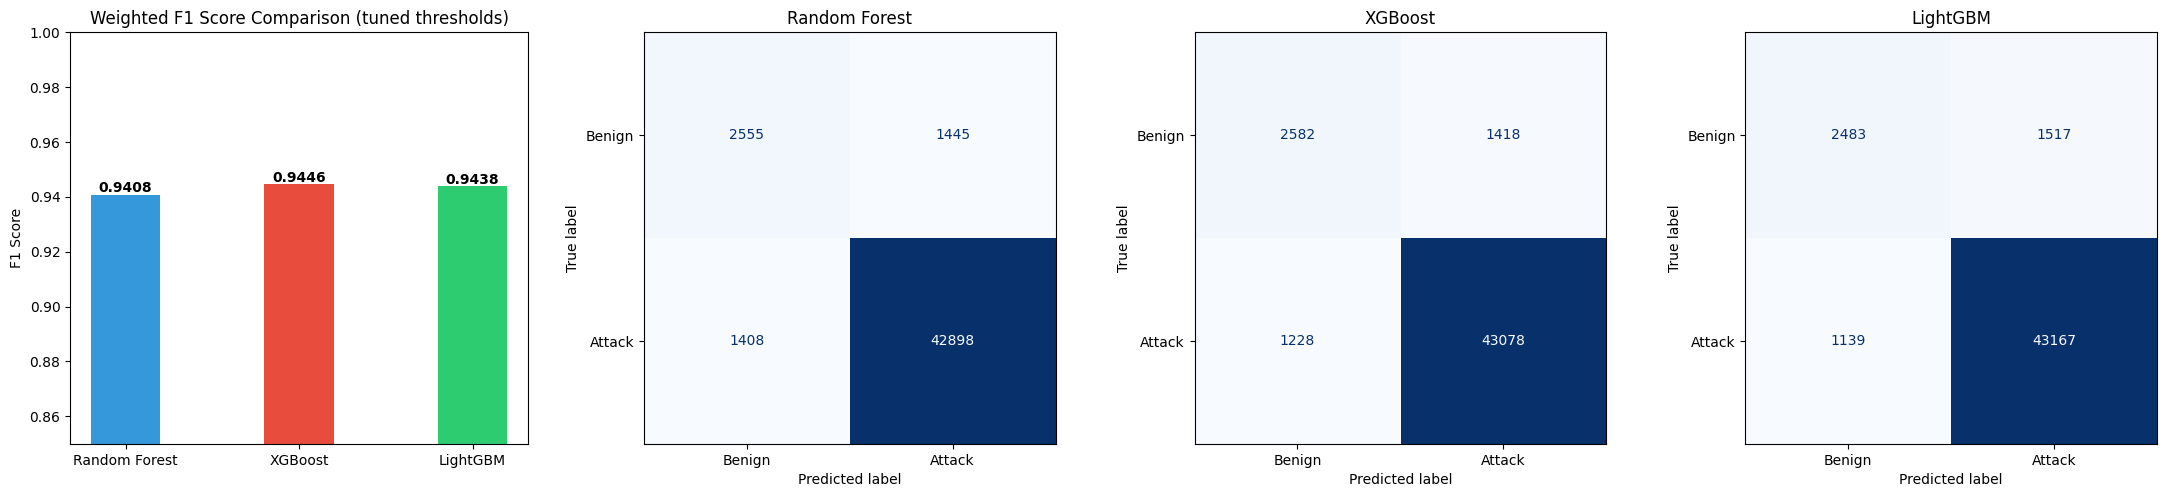

& Comparison chart (tuned) saved.


In [8]:
# === Compare all 3 (tuned thresholds) + Confusion Matrices ===

results = {
    'Random Forest': (rf_preds_tuned, rf_f1_weighted),
    'XGBoost'      : (xgb_preds_tuned, xgb_f1_weighted),
    'LightGBM'     : (lgb_preds_tuned, lgb_f1_weighted),
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

models  = list(results.keys())
f1s     = [v[1] for v in results.values()]
colors  = ['#3498db', '#e74c3c', '#2ecc71']

# F1 comparison bar chart
axes[0].bar(models, f1s, color=colors, width=0.4)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('Weighted F1 Score Comparison (tuned thresholds)')
axes[0].set_ylabel('F1 Score')

for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Confusion matrices (tuned)
for ax, (name, (preds, _)) in zip(axes[1:], results.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('phase1_model_comparison_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("& Comparison chart (tuned) saved.")

Calculating SHAP values for XGBoost (champion model, tuned threshold)...


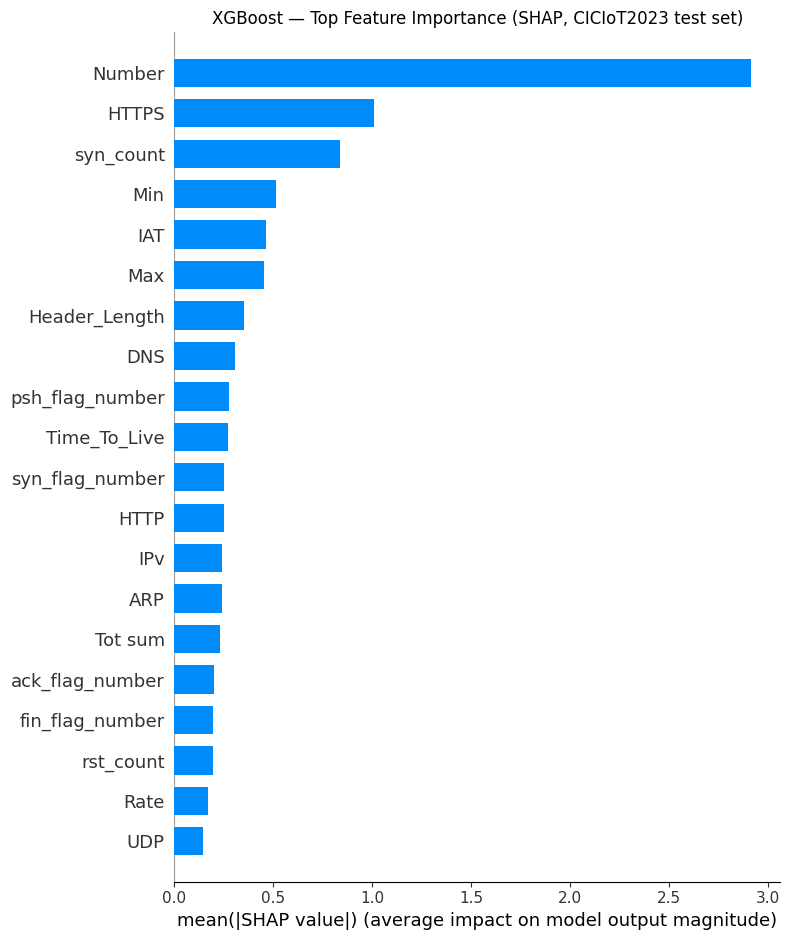

✅ SHAP chart saved.


In [9]:
import shap

print("Calculating SHAP values for XGBoost (champion model, tuned threshold)...")
explainer = shap.TreeExplainer(xgb_model)

# You can keep this; it's a speed-friendly sample of the test set
shap_values = explainer.shap_values(X_test[:500])

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test[:500],
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('XGBoost — Top Feature Importance (SHAP, CICIoT2023 test set)')
plt.tight_layout()
plt.savefig('phase1_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP chart saved.")

In [10]:
rf_model = rf  # fix variable name

In [11]:
import joblib
os.makedirs(os.path.expanduser("~/sentinelmesh/models"), exist_ok=True)
joblib.dump(rf,        os.path.expanduser("~/sentinelmesh/models/rf_v1.pkl"))
joblib.dump(xgb_model, os.path.expanduser("~/sentinelmesh/models/xgb_v1.pkl"))
joblib.dump(lgb_model, os.path.expanduser("~/sentinelmesh/models/lgb_v1.pkl"))
print("✅ Models saved.")

✅ Models saved.
